### 1. Import Libraries

In [1]:
from sklearn import set_config

set_config(transform_output="pandas")

In [62]:
import numpy as np
import pandas as pd
import sklearn
import warnings
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from feature_engine.encoding import RareLabelEncoder, MeanEncoder, CountFrequencyEncoder
from sklearn.preprocessing import(OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, PowerTransformer, FunctionTransformer)
from feature_engine.datetime import DatetimeFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.selection import SelectBySingleFeaturePerformance
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

### 2. Display Settings

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
sklearn.set_config(transform_output = "pandas")

In [4]:
warnings.filterwarnings("ignore")

### 3. Read the Data

In [5]:
path = r"C:\Users\smrts\Desktop\flight-price-prediction AWS Sagemaker\data\train.csv"

train= pd.read_csv(path)
train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-21,Bangalore,New Delhi,08:55:00,19:10:00,615,1.0,In-flight meal not included,7832
1,Jet Airways,2019-03-27,Delhi,Cochin,17:30:00,04:25:00,655,1.0,In-flight meal not included,6540
2,GoAir,2019-03-09,Bangalore,New Delhi,11:40:00,14:35:00,175,0.0,No Info,7305
3,Air India,2019-06-12,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8366
4,Jet Airways,2019-03-12,Bangalore,New Delhi,22:55:00,07:40:00,525,1.0,In-flight meal not included,11087
...,...,...,...,...,...,...,...,...,...,...
6690,Jet Airways,2019-03-21,Delhi,Cochin,10:45:00,18:50:00,1925,2.0,No Info,11093
6691,Air India,2019-05-01,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8891
6692,Jet Airways,2019-06-01,Delhi,Cochin,14:00:00,19:00:00,300,1.0,In-flight meal not included,10262
6693,Air Asia,2019-06-24,Delhi,Cochin,07:55:00,13:25:00,330,1.0,No Info,6152


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6695 entries, 0 to 6694
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          6695 non-null   str    
 1   date_of_journey  6695 non-null   str    
 2   source           6695 non-null   str    
 3   destination      6695 non-null   str    
 4   dep_time         6695 non-null   str    
 5   arrival_time     6695 non-null   str    
 6   duration         6695 non-null   int64  
 7   total_stops      6694 non-null   float64
 8   additional_info  6695 non-null   str    
 9   price            6695 non-null   int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 523.2 KB


- splitting data into X_train(input variables) and Y_train (target column = price)

In [7]:
X_train = train.drop(columns = "price")
y_train = train.price.copy()

### 4. Transformation Operations(column-wise)

#### 4.1 airline

In [8]:
X_train.airline

0       Jet Airways
1       Jet Airways
2             GoAir
3         Air India
4       Jet Airways
           ...     
6690    Jet Airways
6691      Air India
6692    Jet Airways
6693       Air Asia
6694      Air India
Name: airline, Length: 6695, dtype: str

In [9]:
!pip install feature-engine

In [9]:
air_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("grouper", RareLabelEncoder(tol = 0.1, replace_with ="Other", n_categories =2)),
    ("encoder", OneHotEncoder(sparse_output = False, handle_unknown = "ignore"))
    
])

air_transformer.fit_transform(X_train.loc[:,["airline"]])

,airline_Air India,airline_Indigo,airline_Jet Airways,airline_Multiple Carriers,airline_Other
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
6690,0.0,0.0,1.0,0.0,0.0
6691,1.0,0.0,0.0,0.0,0.0
6692,0.0,0.0,1.0,0.0,0.0
6693,0.0,0.0,0.0,0.0,1.0


### 4.2 date_of_journey

In [10]:
X_train.date_of_journey

0       2019-03-21
1       2019-03-27
2       2019-03-09
3       2019-06-12
4       2019-03-12
           ...    
6690    2019-03-21
6691    2019-05-01
6692    2019-06-01
6693    2019-06-24
6694    2019-03-01
Name: date_of_journey, Length: 6695, dtype: str

In [11]:
feature_to_extract = ["month","week", "day_of_week", "day_of_year", "day_of_month", "weekend"]

doj_transformer = Pipeline(steps = [
    ("dt", DatetimeFeatures(features_to_extract= feature_to_extract, yearfirst= True, format= "mixed")),
    ("scaler", MinMaxScaler())
    
])

doj_transformer.fit_transform(X_train.loc[:, ["date_of_journey"]])

,date_of_journey_month,date_of_journey_week,date_of_journey_day_of_week,date_of_journey_day_of_year,date_of_journey_day_of_month,date_of_journey_weekend
0,0.000000,0.176471,0.500000,0.169492,0.769231,0.0
1,0.000000,0.235294,0.333333,0.220339,1.000000,0.0
2,0.000000,0.058824,0.833333,0.067797,0.307692,1.0
3,1.000000,0.882353,0.333333,0.872881,0.423077,0.0
4,0.000000,0.117647,0.166667,0.093220,0.423077,0.0
...,...,...,...,...,...,...
6690,0.000000,0.176471,0.500000,0.169492,0.769231,0.0
6691,0.666667,0.529412,0.333333,0.516949,0.000000,0.0
6692,1.000000,0.764706,0.833333,0.779661,0.000000,1.0
6693,1.000000,1.000000,0.000000,0.974576,0.884615,0.0


### 4.3 source and destination 

In [12]:
X_train.source

0       Bangalore
1           Delhi
2       Bangalore
3         Kolkata
4       Bangalore
          ...    
6690        Delhi
6691      Kolkata
6692        Delhi
6693        Delhi
6694    Bangalore
Name: source, Length: 6695, dtype: str

In [13]:
X_train.destination

0       New Delhi
1          Cochin
2       New Delhi
3        Banglore
4       New Delhi
          ...    
6690       Cochin
6691     Banglore
6692       Cochin
6693       Cochin
6694    New Delhi
Name: destination, Length: 6695, dtype: str

In [14]:
location_subset = X_train.loc[:, ["source", "destination"]]
location_subset

,source,destination
0,Bangalore,New Delhi
1,Delhi,Cochin
2,Bangalore,New Delhi
3,Kolkata,Banglore
4,Bangalore,New Delhi
...,...,...
6690,Delhi,Cochin
6691,Kolkata,Banglore
6692,Delhi,Cochin
6693,Delhi,Cochin


- MeanEncoder() replaces categories by the mean value of the target for each category.
- Mean Encoding : for each unique category, it'll calculate the avg price & avg value of the target column cat1 ka avg price calculate then use that as encoding for cat1 

In [15]:
location_pipe1 = Pipeline(steps = [
    ("grouper", RareLabelEncoder(tol = 0.1, replace_with = "Other", n_categories = 2)),
    ("encoder", MeanEncoder()),
    ("scaler", PowerTransformer())
])

location_pipe1.fit_transform(location_subset, y_train)

,source,destination
0,-0.857930,-0.736484
1,1.065418,1.061694
2,-0.857930,-0.736484
3,-0.203927,-0.224351
4,-0.857930,-0.736484
...,...,...
6690,1.065418,1.061694
6691,-0.203927,-0.224351
6692,1.065418,1.061694
6693,1.065418,1.061694


In [16]:
#check how many north cities are there out of source and destination
np.union1d(
    X_train.source.unique(),
    X_train.destination.unique()
)

array(['Bangalore', 'Banglore', 'Chennai', 'Cochin', 'Delhi', 'Hyderabad',
       'Kolkata', 'Mumbai', 'New Delhi'], dtype=object)

In [17]:
def is_north(X): #X -> some df that will be passed 
    columns = X.columns.to_list() # storing columns of df
    north_cities = ["Delhi", "Kolkata", "Mumbai", "New Delhi"]
    return (
        X
        .assign(**{ #creating new features in loop assign ** is used 
            f"{col}_is_north": X.loc[:, col]. isin(north_cities).astype(int) #true->1 false->0
            for col in columns
        })
        .drop(columns = columns) #keeping only city is north / south
    )

#  not sklearn compatible -> is_north(location_subset) 
#use function transformer 
FunctionTransformer(func = is_north).fit_transform(location_subset)

,source_is_north,destination_is_north
0,0,1
1,1,0
2,0,1
3,1,0
4,0,1
...,...,...
6690,1,0
6691,1,0
6692,1,0
6693,1,0


In [18]:
location_transformer = FeatureUnion(transformer_list = [
    ("part1", location_pipe1),
    ("part2", FunctionTransformer(func= is_north))
])

location_transformer.fit_transform(location_subset, y_train)

,part1__source,part1__destination,part2__source_is_north,part2__destination_is_north
0,-0.857930,-0.736484,0,1
1,1.065418,1.061694,1,0
2,-0.857930,-0.736484,0,1
3,-0.203927,-0.224351,1,0
4,-0.857930,-0.736484,0,1
...,...,...,...,...
6690,1.065418,1.061694,1,0
6691,-0.203927,-0.224351,1,0
6692,1.065418,1.061694,1,0
6693,1.065418,1.061694,1,0


### 4.4 dep_time & arrival_time

In [19]:
X_train.dep_time

0       08:55:00
1       17:30:00
2       11:40:00
3       09:25:00
4       22:55:00
          ...   
6690    10:45:00
6691    09:25:00
6692    14:00:00
6693    07:55:00
6694    11:50:00
Name: dep_time, Length: 6695, dtype: str

In [20]:
X_train.arrival_time

0       19:10:00
1       04:25:00
2       14:35:00
3       18:30:00
4       07:40:00
          ...   
6690    18:50:00
6691    18:30:00
6692    19:00:00
6693    13:25:00
6694    08:55:00
Name: arrival_time, Length: 6695, dtype: str

In [21]:
time_subset = X_train.loc[:, ["dep_time", "arrival_time"]]
time_subset

,dep_time,arrival_time
0,08:55:00,19:10:00
1,17:30:00,04:25:00
2,11:40:00,14:35:00
3,09:25:00,18:30:00
4,22:55:00,07:40:00
...,...,...
6690,10:45:00,18:50:00
6691,09:25:00,18:30:00
6692,14:00:00,19:00:00
6693,07:55:00,13:25:00


In [22]:
time_pipe1 = Pipeline(steps= [
    ("dt", DatetimeFeatures(features_to_extract= ["hour", "minute"])),
    ("scaler", MinMaxScaler())
])

time_pipe1.fit_transform(time_subset)

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute
0,0.347826,1.000000,0.826087,0.181818
1,0.739130,0.545455,0.173913,0.454545
2,0.478261,0.727273,0.608696,0.636364
3,0.391304,0.454545,0.782609,0.545455
4,0.956522,1.000000,0.304348,0.727273
...,...,...,...,...
6690,0.434783,0.818182,0.782609,0.909091
6691,0.391304,0.454545,0.782609,0.545455
6692,0.608696,0.000000,0.826087,0.000000
6693,0.304348,1.000000,0.565217,0.454545


In [23]:
#using hour info-> create new category for part of the day: morning, noon, eve, night
def part_of_the_day(X, morning=4, noon=12, eve=16, night= 20):
    columns = X.columns.to_list() #store col of df to list
    #custom tranformer; thus, datetime format conversion required (no sklearn) 
    X_temp = X.assign(**{
        col : pd.to_datetime(X.loc[:, col]).dt.hour
    for col in columns
    })
    return(
        X_temp
        .assign(**{
            f"{col}_part_of_day":np.select(
                [X_temp.loc[:, col].between(morning, noon, inclusive= "left"),
                 X_temp.loc[:, col].between(noon, eve, inclusive= "left"),
                 X_temp.loc[:, col].between(eve, night, inclusive= "left")],
                ["morning", "afternoon","evening"],
                default = "night"
            )
            for col in columns
        })
        .drop(columns = columns)
    )

FunctionTransformer(func= part_of_the_day).fit_transform(time_subset)

,dep_time_part_of_day,arrival_time_part_of_day
0,morning,evening
1,evening,morning
2,morning,afternoon
3,morning,evening
4,night,morning
...,...,...
6690,morning,evening
6691,morning,evening
6692,afternoon,evening
6693,morning,afternoon


In [24]:
time_pipe2= Pipeline(steps= [
    ("part1", FunctionTransformer(func= part_of_the_day)),
    ("encoder", CountFrequencyEncoder()),
    ("scaler", MinMaxScaler())
])
time_pipe2.fit_transform(time_subset)

,dep_time_part_of_day,arrival_time_part_of_day
0,1.000000,0.667335
1,0.202685,0.952906
2,1.000000,0.000000
3,1.000000,0.667335
4,0.174101,0.952906
...,...,...
6690,1.000000,0.667335
6691,1.000000,0.667335
6692,0.000000,0.667335
6693,1.000000,0.000000


In [25]:
#combine pipe1 and pipe 2 using Feature union
time_transformer = FeatureUnion(transformer_list= [
    ("part1", time_pipe1),
    ("part2", time_pipe2)
])

time_transformer.fit_transform(time_subset)

,0_0,0_1,0_2,0_3,1_0,1_1
0,0.347826,1.000000,0.826087,0.181818,1.000000,0.667335
1,0.739130,0.545455,0.173913,0.454545,0.202685,0.952906
2,0.478261,0.727273,0.608696,0.636364,1.000000,0.000000
3,0.391304,0.454545,0.782609,0.545455,1.000000,0.667335
4,0.956522,1.000000,0.304348,0.727273,0.174101,0.952906
...,...,...,...,...,...,...
6690,0.434783,0.818182,0.782609,0.909091,1.000000,0.667335
6691,0.391304,0.454545,0.782609,0.545455,1.000000,0.667335
6692,0.608696,0.000000,0.826087,0.000000,0.000000,0.667335
6693,0.304348,1.000000,0.565217,0.454545,1.000000,0.000000


### 4.5 duration

In [26]:
X_train.duration

0        615
1        655
2        175
3        545
4        525
        ... 
6690    1925
6691     545
6692     300
6693     330
6694    1265
Name: duration, Length: 6695, dtype: int64

In [59]:
#if passed entire dataset with custom percentiles
#RBFPercentileSimilarity().fit_transform(X_train)

In [44]:
(
    X_train
    .duration
    .quantile([0.25, 0.5, 0.75])
    .values #converts the quantiles -> arrays
    .reshape(-1, 1)
    #.shape # gives 1D array but we want (3,1) ie rows kitne bhi, but column only 1
    .shape
)

(3, 1)

- the above code is for understanding 

In [27]:
class RBFPercentileSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, variables= None, percentiles= [0.25, 0.5, 0.75], gamma= 0.1):
        self.variables = variables
        self.percentiles= percentiles
        self.gamma = gamma

    def fit(self, X, y=None): #paas values in this func 
        if not self.variables: #if X ie variables not given by user as i/p 
            self.variables= X.select_dtypes(include= "number").columns.to_list() #store numeric columns and apply this func on them
          #the following code iterates over all the col and store values as a dictionary   
        self.reference_values = {
            col: (
                X
                .loc[:, col]
                .quantile(self.percentiles)
                .values
                .reshape(-1,1)
             )
             for col in self.variables
        }
          
        return self
    def transform(self, X): # for creating the 25th, 50th, 75th percentiles of duration col
        objects= []
        for col in self.variables:
            columns = [f"{col}_rbf_{int(percentile*100)}" for percentile in self.percentiles]
            obj = pd.DataFrame(
                data = rbf_kernel(X.loc[:, [col]], Y= self.reference_values[col], gamma= self.gamma),
                columns = columns
            )
            objects.append(obj)
        return pd.concat(objects, axis= 1 )  

In [56]:
RBFPercentileSimilarity().fit_transform(X_train.loc[:, ["duration"]])

,duration_rbf_25,duration_rbf_50,duration_rbf_75
0,0.000000,0.000000e+00,0.0
1,0.000000,0.000000e+00,0.0
2,0.082085,0.000000e+00,0.0
3,0.000000,6.293989e-54,0.0
4,0.000000,1.691898e-10,0.0
...,...,...,...
6690,0.000000,0.000000e+00,0.0
6691,0.000000,6.293989e-54,0.0
6692,0.000000,0.000000e+00,0.0
6693,0.000000,0.000000e+00,0.0


In [29]:
def duration_category(X, short=180, med=400):
	return (
		X
		.assign(duration_cat=np.select([X.duration.lt(short),
									    X.duration.between(short, med, inclusive="left")],
									   ["short", "medium"],
									   default="long"))
		.drop(columns="duration")
	)

In [30]:
# creating a binary column (for duration >= 1000 min or <1000 min)
def is_over(X, value= 1000):
    return (
        X
        .assign(**{
            f"duration_over_{value}": X.duration.ge(value).astype(int)
        })
        .drop(columns= "duration")
    )

In [33]:
duration_pipe1= Pipeline(steps= [
    ("rbf", RBFPercentileSimilarity()),
    ("scaler", PowerTransformer())
])

duration_pipe2= Pipeline(steps= [
    ("cat", FunctionTransformer(func= duration_category)),
    ("encoder", OrdinalEncoder(categories= [["short", "medium", "long"]]))
])

duration_union= FeatureUnion(transformer_list= [
    ("part1", duration_pipe1),
    ("part2", duration_pipe2),
    ("part3", FunctionTransformer(func= is_over)),
    ("part4", StandardScaler())
])

#code starts running from here
duration_transformer= Pipeline(steps= [
    ("outliers", Winsorizer(capping_method= "iqr", fold= 1.5,)), #handle outliers
    ("imputer", SimpleImputer(strategy= "median")), #handle missing values
    ("union", duration_union) #use above code for feature union
])

duration_transformer.fit_transform(X_train.loc[:, ["duration"]])

,0_0,0_1,0_2,1_0,2_0,3_0
0,-0.364262,-0.106983,-0.101517,2.0,0,-0.033916
1,-0.364262,-0.106983,-0.101517,2.0,0,0.046422
2,2.373008,-0.106983,-0.101517,0.0,0,-0.917631
3,-0.364262,-0.106983,-0.101517,2.0,0,-0.174507
4,-0.364262,-0.106983,-0.101517,2.0,0,-0.214676
...,...,...,...,...,...,...
6690,-0.364262,-0.106983,-0.101517,2.0,1,2.597145
6691,-0.364262,-0.106983,-0.101517,2.0,0,-0.174507
6692,-0.364262,-0.106983,-0.101517,1.0,0,-0.666576
6693,-0.364262,-0.106983,-0.101517,1.0,0,-0.606322


### 4.6 total_stops

In [34]:
X_train.total_stops

0       1.0
1       1.0
2       0.0
3       1.0
4       1.0
       ... 
6690    2.0
6691    1.0
6692    1.0
6693    1.0
6694    1.0
Name: total_stops, Length: 6695, dtype: float64

In [36]:
# if total_stops = 0 ; ie it is direct flight
# if total_stops = 0 ; ie it is direct flight
#use direct = 1, indirect =0

def is_direct(X):
    return X.assign(is_direct_flight= X.total_stops.eq(0).astype(int))

total_stops_transformer= Pipeline(steps= [
    ("imputer", SimpleImputer(strategy= "most_frequent")),
    ("", FunctionTransformer(func= is_direct))
])

total_stops_transformer.fit_transform(X_train.loc[:, ["total_stops"]])

,total_stops,is_direct_flight
0,1.0,0
1,1.0,0
2,0.0,1
3,1.0,0
4,1.0,0
...,...,...
6690,2.0,0
6691,1.0,0
6692,1.0,0
6693,1.0,0


### 4.7 additional_info

In [38]:
info_pipe1= Pipeline(steps= [
    ("group", RareLabelEncoder(tol= 0.1, n_categories= 2, replace_with= "Other")),
    ("encoder", OneHotEncoder(handle_unknown= "ignore", sparse_output= False))
])

info_pipe1.fit_transform(X_train.loc[:, ["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No Info,additional_info_Other
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0
...,...,...,...
6690,0.0,1.0,0.0
6691,0.0,1.0,0.0
6692,1.0,0.0,0.0
6693,0.0,1.0,0.0


In [39]:
#creating binary column;
# for No_info : 0
# for all others (with info) : 1

def have_info(X):
    return X.assign(additional_info= X.additional_info.ne("No Info").astype(int))

In [41]:
info_union= FeatureUnion(transformer_list= [
    ("part1", info_pipe1),
    ("part2", FunctionTransformer(func= have_info))
])

In [43]:
info_transformer= Pipeline(steps=[
    ("imputer", SimpleImputer(strategy= "constant", fill_value= "unknown")),
    ("union", info_union)
])

info_transformer.fit_transform(X_train.loc[:, ["additional_info"]])

,part1__additional_info_In-flight meal not included,part1__additional_info_No Info,part1__additional_info_Other,part2__additional_info
0,1.0,0.0,0.0,1
1,1.0,0.0,0.0,1
2,0.0,1.0,0.0,0
3,0.0,1.0,0.0,0
4,1.0,0.0,0.0,1
...,...,...,...,...
6690,0.0,1.0,0.0,0
6691,0.0,1.0,0.0,0
6692,1.0,0.0,0.0,1
6693,0.0,1.0,0.0,0


In [12]:
X_train.columns.to_list()

['airline',
 'date_of_journey',
 'source',
 'destination',
 'dep_time',
 'arrival_time',
 'duration',
 'total_stops',
 'additional_info']

### 5. Column Transformer

In [28]:
column_transformer = ColumnTransformer(transformers= [
    ("air", air_transformer, ["airline"])
])

column_transformer.fit_transform(X_train)

,air__airline_Air India,air__airline_Indigo,air__airline_Jet Airways,air__airline_Multiple Carriers,air__airline_Other
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
6690,0.0,0.0,1.0,0.0,0.0
6691,1.0,0.0,0.0,0.0,0.0
6692,0.0,0.0,1.0,0.0,0.0
6693,0.0,0.0,0.0,0.0,1.0


- column transfoer (i/p is list of tuples)
- ("name for identification", transformation(s) to apply, ['column name'])

In [74]:
#with full columns
column_transformer = ColumnTransformer(transformers= [
    ("air", air_transformer, ["airline"]),
    ("doj", doj_transformer, ["date_of_journey"]),
    ("location", location_transformer, ["source", "destination"]),
    #("dur", duration_transformer, ["duration"]),
    #("time", time_transformer, ["dep_time", "arrival_time"]),
    #("stops", total_stops_transformer, ["total_stops"]),
    ("info", info_transformer, ["additional_info"])
], remainder= "passthrough")

column_transformer.fit_transform(X_train, y_train)

,air__airline_Air India,air__airline_Indigo,air__airline_Jet Airways,air__airline_Multiple Carriers,air__airline_Other,doj__date_of_journey_month,doj__date_of_journey_week,doj__date_of_journey_day_of_week,doj__date_of_journey_day_of_year,doj__date_of_journey_day_of_month,doj__date_of_journey_weekend,location__part1__source,location__part1__destination,location__part2__source_is_north,location__part2__destination_is_north,info__part1__additional_info_In-flight meal not included,info__part1__additional_info_No Info,info__part1__additional_info_Other,info__part2__additional_info,remainder__dep_time,remainder__arrival_time,remainder__duration,remainder__total_stops
0,0.0,0.0,1.0,0.0,0.0,0.000000,0.176471,0.500000,0.169492,0.769231,0.0,-0.857930,-0.736484,0,1,1.0,0.0,0.0,1,08:55:00,19:10:00,615,1.0
1,0.0,0.0,1.0,0.0,0.0,0.000000,0.235294,0.333333,0.220339,1.000000,0.0,1.065418,1.061694,1,0,1.0,0.0,0.0,1,17:30:00,04:25:00,655,1.0
2,0.0,0.0,0.0,0.0,1.0,0.000000,0.058824,0.833333,0.067797,0.307692,1.0,-0.857930,-0.736484,0,1,0.0,1.0,0.0,0,11:40:00,14:35:00,175,0.0
3,1.0,0.0,0.0,0.0,0.0,1.000000,0.882353,0.333333,0.872881,0.423077,0.0,-0.203927,-0.224351,1,0,0.0,1.0,0.0,0,09:25:00,18:30:00,545,1.0
4,0.0,0.0,1.0,0.0,0.0,0.000000,0.117647,0.166667,0.093220,0.423077,0.0,-0.857930,-0.736484,0,1,1.0,0.0,0.0,1,22:55:00,07:40:00,525,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6690,0.0,0.0,1.0,0.0,0.0,0.000000,0.176471,0.500000,0.169492,0.769231,0.0,1.065418,1.061694,1,0,0.0,1.0,0.0,0,10:45:00,18:50:00,1925,2.0
6691,1.0,0.0,0.0,0.0,0.0,0.666667,0.529412,0.333333,0.516949,0.000000,0.0,-0.203927,-0.224351,1,0,0.0,1.0,0.0,0,09:25:00,18:30:00,545,1.0
6692,0.0,0.0,1.0,0.0,0.0,1.000000,0.764706,0.833333,0.779661,0.000000,1.0,1.065418,1.061694,1,0,1.0,0.0,0.0,1,14:00:00,19:00:00,300,1.0
6693,0.0,0.0,0.0,0.0,1.0,1.000000,1.000000,0.000000,0.974576,0.884615,0.0,1.065418,1.061694,1,0,0.0,1.0,0.0,0,07:55:00,13:25:00,330,1.0


### 5. Feature Selection

In [75]:
estimator= RandomForestRegressor(n_estimators= 10, max_depth= 3, random_state= 42)

selector= SelectBySingleFeaturePerformance(
    estimator= estimator,
    scoring= "r2",
    threshold= 0.1 # for whichever features the r2 score >= 0.1; retain them else drop them
)

### 6. Placing everything togeher

In [76]:
preprocessor= Pipeline(steps= [
    ("ct", column_transformer),
    ("selector", selector)
])

preprocessor.fit_transform(X_train, y_train)

,air__airline_Indigo,air__airline_Jet Airways,air__airline_Other,doj__date_of_journey_week,doj__date_of_journey_day_of_year,location__part1__source,location__part1__destination,remainder__dep_time,remainder__arrival_time,remainder__duration,remainder__total_stops
0,0.0,1.0,0.0,0.176471,0.169492,-0.857930,-0.736484,08:55:00,19:10:00,615,1.0
1,0.0,1.0,0.0,0.235294,0.220339,1.065418,1.061694,17:30:00,04:25:00,655,1.0
2,0.0,0.0,1.0,0.058824,0.067797,-0.857930,-0.736484,11:40:00,14:35:00,175,0.0
3,0.0,0.0,0.0,0.882353,0.872881,-0.203927,-0.224351,09:25:00,18:30:00,545,1.0
4,0.0,1.0,0.0,0.117647,0.093220,-0.857930,-0.736484,22:55:00,07:40:00,525,1.0
...,...,...,...,...,...,...,...,...,...,...,...
6690,0.0,1.0,0.0,0.176471,0.169492,1.065418,1.061694,10:45:00,18:50:00,1925,2.0
6691,0.0,0.0,0.0,0.529412,0.516949,-0.203927,-0.224351,09:25:00,18:30:00,545,1.0
6692,0.0,1.0,0.0,0.764706,0.779661,1.065418,1.061694,14:00:00,19:00:00,300,1.0
6693,0.0,0.0,1.0,1.000000,0.974576,1.065418,1.061694,07:55:00,13:25:00,330,1.0


### 7. Visualisations

In [54]:
preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ct', ...), ('selector', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['airline','date_of_journey','source',...,'duration','total_stops', 'additional_info']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('air', ...), ('doj', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [77]:
preprocessor.named_steps

{'ct': ColumnTransformer(remainder='passthrough',
                   transformers=[('air',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('grouper',
                                                   RareLabelEncoder(n_categories=2,
                                                                    replace_with='Other',
                                                                    tol=0.1)),
                                                  ('encoder',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False))]),
                                  ['airline']),
                                 ('doj',
                                  Pipeline(steps=[('dt',
                                                   

In [57]:
preprocessor.named_steps.keys()

dict_keys(['ct', 'selector'])

In [70]:
preprocessor.named_steps["selector"] #to acess selector

,estimator,RandomForestR...ndom_state=42)
,scoring,'r2'
,threshold,0.1
,cv,3
,groups,None
,variables,None
,confirm_variables,False
Name,Type,Value
feature_names_in_,list,"['tm..._0', 'tm..._1', 'tm..._2', 'tm..._3', ...]"
feature_performance_,dict,"{'tm..._0': np.float64(0....8488187393068), 'tm..._1': np.float64(0....7620333701603), 'tm..._2': np.float64(0.1808198566845403), 'tm..._3': np.float64(0....4611992796467), ...}"
feature_performance_std_,dict,"{'tm..._0': np.float64(0....3614124306914), 'tm..._1': np.float64(0....0648096010274), 'tm..._2': np.float64(0....2515042469517), 'tm..._3': np.float64(0....0346787800654), ...}"


In [79]:
feature_performances = preprocessor.named_steps["selector"].feature_performance_
feature_performances # stores every column with its resp r2 scores 

{'air__airline_Air India': np.float64(0.0016858488187393068),
 'air__airline_Indigo': np.float64(0.12827620333701603),
 'air__airline_Jet Airways': np.float64(0.1808198566845403),
 'air__airline_Multiple Carriers': np.float64(0.018604611992796467),
 'air__airline_Other': np.float64(0.10397754039356721),
 'doj__date_of_journey_month': np.float64(0.08907386829479753),
 'doj__date_of_journey_week': np.float64(0.18569991444411282),
 'doj__date_of_journey_day_of_week': np.float64(0.004664789869158821),
 'doj__date_of_journey_day_of_year': np.float64(0.22920092220662194),
 'doj__date_of_journey_day_of_month': np.float64(0.034223276788402646),
 'doj__date_of_journey_weekend': np.float64(-0.0009403217440686618),
 'location__part1__source': np.float64(0.1267120700518518),
 'location__part1__destination': np.float64(0.13064205945980614),
 'location__part2__source_is_north': np.float64(0.029331367522183977),
 'location__part2__destination_is_north': np.float64(0.029331367522183977),
 'info__part1

In [80]:
#sort dict based on r2 scores
sorted_feat_imp = dict(sorted(feature_performances.items(), key= lambda val: val[1]))
sorted_feat_imp

{'info__part1__additional_info_No Info': np.float64(-0.001132211161403977),
 'info__part2__additional_info': np.float64(-0.001132211161403977),
 'doj__date_of_journey_weekend': np.float64(-0.0009403217440686618),
 'info__part1__additional_info_In-flight meal not included': np.float64(0.0014426619953507396),
 'air__airline_Air India': np.float64(0.0016858488187393068),
 'doj__date_of_journey_day_of_week': np.float64(0.004664789869158821),
 'info__part1__additional_info_Other': np.float64(0.01760748529752132),
 'air__airline_Multiple Carriers': np.float64(0.018604611992796467),
 'location__part2__source_is_north': np.float64(0.029331367522183977),
 'location__part2__destination_is_north': np.float64(0.029331367522183977),
 'doj__date_of_journey_day_of_month': np.float64(0.034223276788402646),
 'doj__date_of_journey_month': np.float64(0.08907386829479753),
 'air__airline_Other': np.float64(0.10397754039356721),
 'location__part1__source': np.float64(0.1267120700518518),
 'air__airline_Ind

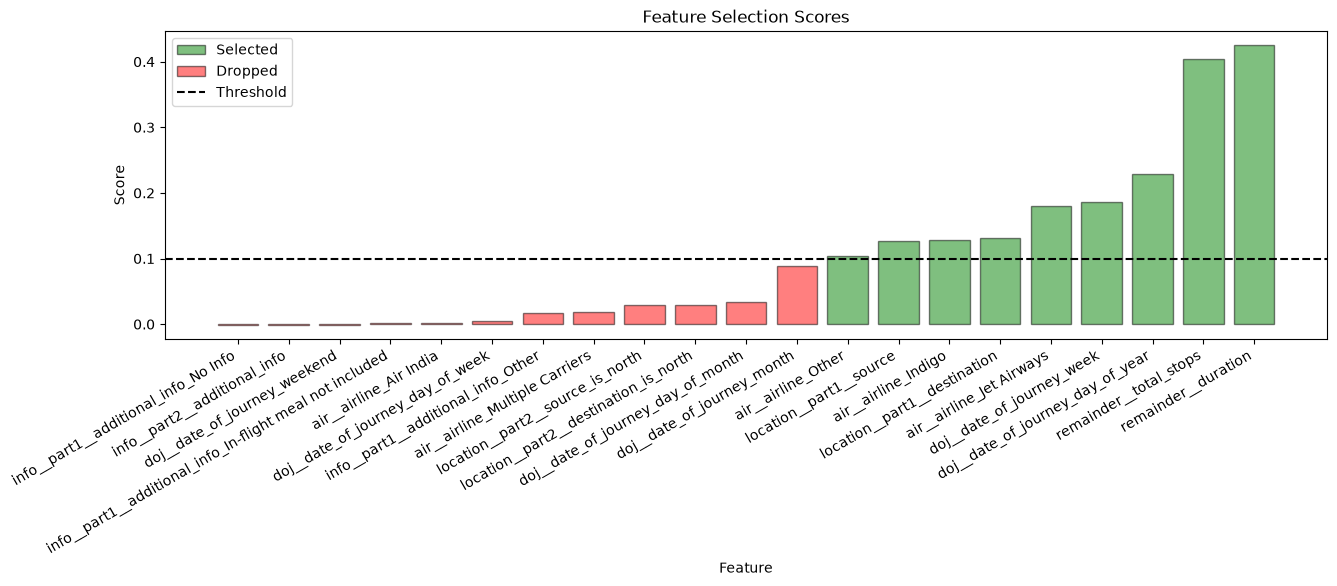

In [81]:
#use matplotlib to plot:
#features that retained 
#features that dropped
THRESHOLD = 0.1

selected_bar = None
dropped_bar = None
colors = ["red" if score < THRESHOLD else "green" for score in sorted_feat_imp.values()]


fig, ax = plt.subplots(figsize=(15, 4)) 

for i, (feature, score) in enumerate(sorted_feat_imp.items()):
	params = dict(
		x=i,
		height=score,
		edgecolor="black",
		alpha=0.5
	)
	
	if score < THRESHOLD:
		bar = ax.bar(
			color="red",
			**params
		)
		if not dropped_bar:
			dropped_bar = bar[0]
	else:
		bar = ax.bar(
			color="green",
			**params
		)
		if not selected_bar:
			selected_bar = bar[0]

thresh_line = ax.axhline(
	y=0.1,
	color="black",
	linestyle="--"
)

ax.set_xticks(
	ticks=range(len(sorted_feat_imp)),
	labels=list(sorted_feat_imp.keys()),
	rotation=30,
	ha="right"
)

ax.set(
	xlabel="Feature",
	ylabel="Score",
	title="Feature Selection Scores"
)

ax.legend(
	handles=[selected_bar, dropped_bar, thresh_line],
	labels=["Selected", "Dropped", "Threshold"],
	loc="upper left"
)

plt.show()

- The dataset went upto 23 columns after Feature Engineering
- The Feature Selection algorithm selected 11 features out of that